# 02 — Разбиения A/B и фиксированные RDKit-дескрипторы

Вход — `dataset_internal.csv` из ноутбука 01; опционально `dataset_full.csv`.
Выход — воспроизводимое разбиение по сценариям раздела 2.4 ВКР, физические признаки
и десять RDKit-признаков из итогового эксперимента (раздел 2.6).

| Выборка | Условия относительно train |
|---|---|
| `train` | Обучение |
| `val_unseen_solvent_set`, `test_unseen_solvent_set` — A | Новое вещество и оба новых растворителя |
| `val_unseen_solute`, `test_unseen_solute` — B | Новое вещество; растворители могут быть известны |
| `excluded_A_conflict` | Системы, исключённые для сохранения условий A |

Вещество не пересекается между **любыми двумя из пяти рабочих выборок**.
Растворители A могут пересекаться между validation A и test A, как в дипломе;
их отсутствие гарантируется относительно train. B не требует, чтобы оба растворителя
обязательно присутствовали в train: их фактическая известность отражается в отчёте.

**Почему дескрипторы можно вычислить сейчас:** это детерминированные функции SMILES,
которые не используют растворимость и не обучаются на выборке. Набор заранее фиксирован
по предыдущей работе. Импутацию, масштабирование и любой новый отбор признаков следует
обучать только на train. Изменять набор по результатам нового test нельзя.

## Запуск
1. Проверить пути в параметрах ниже.
2. Выполнить **Restart Kernel → Run All**.
3. Изучить сводку разбиений и `overlap_checks.csv`.
4. Для обучения использовать отдельные CSV в `splits/` и явные списки из `feature_sets.json`.

In [1]:
# При необходимости выполнить, затем перезапустить kernel:
# %pip install numpy pandas matplotlib rdkit

## 1. Параметры и соответствие диплому

Алгоритм повторяет схему исходного `split_preparation.ipynb`: исключение top-10
растворителей из кандидатов A, жадное расширение множества растворителей, исключение
конфликтов A, затем удерживание веществ для B с исключением top-10 частых веществ.
Частоты и доли считаются по кривым, а не по числу точек.

Цели A 5% и B 20% — общие validation+test. Верхние границы мягкие: химические группы
нельзя разрезать ради точной доли. В исходном дипломе A также оказалось меньше цели.
Validation/test делятся приблизительно пополам по числу кривых, сохраняя вещества целиком.

Отличия реализации: перед случайным выбором все множества сортируются, чтобы seed
не зависел от порядка строк или Python hash seed; каждая holdout-часть должна содержать
минимум два вещества. Старое конкретное разбиение не воспроизводится побитно —
сценарии сохранены, данные и детерминизация обновлены. Seed не подбирается по метрикам.

In [2]:
from pathlib import Path
import json
import hashlib
import platform
from datetime import datetime, timezone
from itertools import combinations
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from rdkit import Chem, rdBase
from rdkit.Chem import Descriptors

CFG = {
    "INPUT_INTERNAL": "prepared_data_v1/dataset_internal.csv",
    "INPUT_FULL": "prepared_data_v1/dataset_full.csv",  # None — не переносить full
    "OUTPUT_DIR": "ml_ready/splits_v1",
    "SEED": 42,
    "TOP_SOLVENTS_EXCLUDED_A": 10,
    "A_TARGET_FRAC": 0.05,
    "A_SOFT_MAX_FRAC": 0.08,
    "TOP_SOLUTES_EXCLUDED_B": 10,
    "B_TARGET_FRAC": 0.20,
    "B_SOFT_MAX_FRAC": 0.23,
    "VAL_SHARE": 0.50,
    "ADD_RDKIT": True,
}

DESCRIPTOR_NAMES = ["BalabanJ", "fr_NH0", "FpDensityMorgan3", "EState_VSA3", "MolLogP"]
RDKIT_FEATURES = [f"solv{side}_{name}" for name in DESCRIPTOR_NAMES for side in [1, 2]]
PHYSICAL_FEATURES = ["x1", "x2", "Temperature_bin_K", "logS1", "logS2", "logS_base",
                     "x1_x2", "x1_minus_x2", "abs_x1_minus_x2", "logS1_minus_logS2",
                     "abs_logS1_minus_logS2", "jouyban_0", "jouyban_1", "jouyban_2", "jouyban_3"]
ACTIVE_SPLITS = ["train", "val_unseen_solvent_set", "val_unseen_solute",
                 "test_unseen_solvent_set", "test_unseen_solute"]
SOLUTE = "canon_SMILES_Solute"
S1, S2 = "canon_SMILES_Solvent1", "canon_SMILES_Solvent2"
display(pd.Series(CFG, name="value").to_frame())

,value
INPUT_INTERNAL,prepared_data_v1/dataset_internal.csv
INPUT_FULL,prepared_data_v1/dataset_full.csv
OUTPUT_DIR,ml_ready/splits_v1
SEED,42
TOP_SOLVENTS_EXCLUDED_A,10
A_TARGET_FRAC,0.05
A_SOFT_MAX_FRAC,0.08
TOP_SOLUTES_EXCLUDED_B,10
B_TARGET_FRAC,0.2
B_SOFT_MAX_FRAC,0.23


## 2. Загрузка и проверка единицы группировки

Для построения разбиения используются только идентификаторы, структуры и число кривых.
Значения target и метрики не участвуют в выборе групп.
`system_group_id` объединяет одинаковую систему и температуру даже при разделении
кривых по источникам в ноутбуке 01.

In [3]:
input_path = Path(CFG["INPUT_INTERNAL"])
if not input_path.is_file():
    raise FileNotFoundError(f"Нет {input_path.resolve()}. Укажите результат ноутбука 01.")
internal = pd.read_csv(input_path, low_memory=False)
required = ["experiment_id", "system_group_id", SOLUTE, S1, S2,
            "Temperature_bin_K", "x1", "x2", "logS_mix", "logS1", "logS2"]
missing = sorted(set(required) - set(internal))
if missing:
    raise ValueError(f"Не хватает колонок: {missing}")
if internal.empty or internal[required].isna().any().any():
    raise ValueError("Пустой набор или пропуски в обязательных колонках")
if not internal["x1"].between(0, 1, inclusive="neither").all():
    raise ValueError("Вход должен содержать только внутренние точки")
if not np.allclose(internal["x1"] + internal["x2"], 1., atol=1e-8, rtol=0):
    raise ValueError("x1+x2 != 1")
if not (internal[S1] < internal[S2]).all():
    raise ValueError("Растворители должны быть упорядочены как в ноутбуке 01")
identity = ["system_group_id", SOLUTE, S1, S2, "Temperature_bin_K"]
if not internal.groupby("experiment_id")[identity + ["logS1", "logS2"]].nunique().eq(1).all().all():
    raise ValueError("Внутри experiment_id меняются система, температура или endpoints")
if not internal.groupby("system_group_id")[[SOLUTE, S1, S2, "Temperature_bin_K"]].nunique().eq(1).all().all():
    raise ValueError("system_group_id соответствует нескольким системам")
experiments = internal[["experiment_id"] + identity].drop_duplicates("experiment_id").sort_values("experiment_id").reset_index(drop=True)
print(f"Внутренних измерений: {len(internal):,}; кривых: {len(experiments):,}; веществ: {experiments[SOLUTE].nunique():,}")

Внутренних измерений: 99,852; кривых: 12,703; веществ: 582


## 3. Алгоритм разбиения

Для A выбираются только пары без top-10 растворителей. Начальное ядро — случайный
растворитель; затем в ядро переходят связанные растворители, пока не достигнута цель
или не исчерпаны кандидаты. Оба компонента выбранных пар становятся запрещёнными
для train. Все оставшиеся системы с этими растворителями или веществами A исключаются.

Для B из оставшихся систем выбираются целые вещества до целевого числа кривых.
Остаток становится train. Если корректное непустое разбиение невозможно, код останавливается
с объяснением; правила автоматически не ослабляются.

In [4]:
def all_solvents(frame):
    return set(frame[S1]) | set(frame[S2])

def contains_solvent(frame, values):
    return frame[S1].isin(values) | frame[S2].isin(values)

def frequency(values):
    # Детерминированные tie-breaks: число по убыванию, SMILES по возрастанию.
    counts = values.value_counts().rename_axis("smiles").reset_index(name="n_curves")
    return counts.sort_values(["n_curves", "smiles"], ascending=[False, True]).reset_index(drop=True)

def divide_by_solute(frame, rng, val_share):
    counts = frame.groupby(SOLUTE).size()
    if len(counts) < 2:
        raise ValueError("Для разделения validation/test нужны минимум два вещества")
    order = sorted(counts.index)
    rng.shuffle(order)
    val, test, nv, nt = set(), set(), 0, 0
    for solute in order:
        if nv <= nt and nv < len(frame) * val_share:
            val.add(solute); nv += int(counts[solute])
        else:
            test.add(solute); nt += int(counts[solute])
    if not val:
        moved = sorted(test)[0]; test.remove(moved); val.add(moved)
    if not test:
        moved = sorted(val)[0]; val.remove(moved); test.add(moved)
    return val, test

def create_split_map(exp, cfg):
    if not 0 < cfg["VAL_SHARE"] < 1:
        raise ValueError("VAL_SHARE должен быть между 0 и 1")
    if not 0 < cfg["A_TARGET_FRAC"] <= cfg["A_SOFT_MAX_FRAC"] < 1:
        raise ValueError("Некорректные доли A")
    if not 0 < cfg["B_TARGET_FRAC"] <= cfg["B_SOFT_MAX_FRAC"] < 1:
        raise ValueError("Некорректные доли B")
    if min(cfg["TOP_SOLVENTS_EXCLUDED_A"], cfg["TOP_SOLUTES_EXCLUDED_B"]) < 0:
        raise ValueError("Количество исключаемых частых компонентов должно быть >=0")
    rng = np.random.default_rng(cfg["SEED"])
    e = exp.sort_values("experiment_id").reset_index(drop=True).copy()
    e["split"] = "unassigned"
    n = len(e)
    solvent_counts = frequency(pd.concat([e[S1], e[S2]], ignore_index=True))
    top_a = set(solvent_counts.head(cfg["TOP_SOLVENTS_EXCLUDED_A"])["smiles"])
    candidates = e.loc[~contains_solvent(e, top_a)].copy()
    if candidates.empty or candidates[SOLUTE].nunique() < 2:
        raise ValueError("Нет достаточных кандидатов A после исключения top растворителей. Проверьте данные/порог.")
    available = sorted(all_solvents(candidates))
    rng.shuffle(available)
    core = {available[0]}
    iteration_log = []
    target_a = int(np.ceil(n * cfg["A_TARGET_FRAC"]))
    while True:
        a = candidates.loc[contains_solvent(candidates, core)]
        neighbors = all_solvents(a) - core
        iteration_log.append({"step": len(iteration_log)+1, "n_curves": len(a),
                              "n_solutes": a[SOLUTE].nunique(), "core": sorted(core), "neighbors": sorted(neighbors)})
        if len(a) >= target_a and a[SOLUTE].nunique() >= 2:
            break
        choices = sorted(neighbors - core) or sorted(set(available) - core)
        if not choices:
            break
        rng.shuffle(choices)
        core.add(choices[0])
    val_a, test_a = divide_by_solute(a, rng, cfg["VAL_SHARE"])
    e.loc[e["experiment_id"].isin(a.loc[a[SOLUTE].isin(val_a), "experiment_id"]), "split"] = "val_unseen_solvent_set"
    e.loc[e["experiment_id"].isin(a.loc[a[SOLUTE].isin(test_a), "experiment_id"]), "split"] = "test_unseen_solvent_set"
    forbidden = all_solvents(a)
    conflict = e["split"].eq("unassigned") & (contains_solvent(e, forbidden) | e[SOLUTE].isin(set(a[SOLUTE])))
    e.loc[conflict, "split"] = "excluded_A_conflict"
    b_base = e.loc[e["split"].eq("unassigned")]
    solute_counts = frequency(b_base[SOLUTE])
    top_b = set(solute_counts.head(cfg["TOP_SOLUTES_EXCLUDED_B"])["smiles"])
    b_candidates = b_base.loc[~b_base[SOLUTE].isin(top_b)]
    counts_b = b_candidates.groupby(SOLUTE).size()
    if len(counts_b) < 2:
        raise ValueError("Недостаточно веществ B после исключений A и top веществ. Проверьте отчёт и параметры.")
    order = sorted(counts_b.index)
    rng.shuffle(order)
    selected, total = set(), 0
    target_b = int(round(n * cfg["B_TARGET_FRAC"]))
    max_b = int(round(n * cfg["B_SOFT_MAX_FRAC"]))
    for solute in order:
        if total >= target_b and len(selected) >= 2:
            break
        count = int(counts_b[solute])
        if total + count <= max_b or not selected:
            selected.add(solute); total += count
    for solute in order:
        if total >= target_b and len(selected) >= 2:
            break
        if solute not in selected:
            selected.add(solute); total += int(counts_b[solute])
    b = b_candidates.loc[b_candidates[SOLUTE].isin(selected)]
    val_b, test_b = divide_by_solute(b, rng, cfg["VAL_SHARE"])
    e.loc[e["split"].eq("unassigned") & e[SOLUTE].isin(val_b), "split"] = "val_unseen_solute"
    e.loc[e["split"].eq("unassigned") & e[SOLUTE].isin(test_b), "split"] = "test_unseen_solute"
    e.loc[e["split"].eq("unassigned"), "split"] = "train"
    if any(not e["split"].eq(s).any() for s in ACTIVE_SPLITS):
        raise ValueError("Получена пустая рабочая выборка. Нужен пересмотр параметров по структуре данных, не по метрикам.")
    notes = []
    for name, count, target, softmax in [("A", len(a), target_a, n*cfg["A_SOFT_MAX_FRAC"]),
                                          ("B", len(b), target_b, max_b)]:
        if count < target: notes.append(f"{name}: цель {target} кривых не достигнута; доступно {count}")
        if count > softmax: notes.append(f"{name}: {count} кривых превышает мягкий максимум {softmax:.0f}")
    meta = {"top_solvents_excluded_A": sorted(top_a), "A_core_solvents": sorted(core),
            "A_forbidden_train_solvents": sorted(forbidden), "top_solutes_excluded_B": sorted(top_b),
            "A_target_curves": target_a, "B_target_curves": target_b, "notes": notes}
    return e, meta, pd.DataFrame(iteration_log), solvent_counts, solute_counts

split_map, split_metadata, a_iterations, solvent_counts, solute_counts = create_split_map(experiments, CFG)
for note in split_metadata["notes"]:
    print("Примечание:", note)
display(a_iterations.tail())

Примечание: A: цель 636 кривых не достигнута; доступно 258


,step,n_curves,n_solutes,core,neighbors
15,16,257,34,"[C1CCCCC1, C1COCCO1, CC(=O)CC(C)C, CC(=O)O, CC...","[CS(C)=O, ClC(Cl)(Cl)Cl, O=C1CCCCC1]"
16,17,258,34,"[C1CCCCC1, C1COCCO1, CC(=O)CC(C)C, CC(=O)O, CC...","[CCC(=O)O, CS(C)=O, ClC(Cl)(Cl)Cl]"
17,18,258,34,"[C1CCCCC1, C1COCCO1, CC(=O)CC(C)C, CC(=O)O, CC...","[CS(C)=O, ClC(Cl)(Cl)Cl]"
18,19,258,34,"[C1CCCCC1, C1COCCO1, CC(=O)CC(C)C, CC(=O)O, CC...",[CS(C)=O]
19,20,258,34,"[C1CCCCC1, C1COCCO1, CC(=O)CC(C)C, CC(=O)O, CC...",[]


## 4. Независимые проверки отсутствия пересечений

Проверяется каждое попарное пересечение рабочих выборок по веществам, кривым и
системам. Для A отдельно проверяются оба растворителя относительно train.
Excluded не участвует в обучении или оценке. Дополнительно проверяется независимость
результата от порядка строк входной таблицы.

In [5]:
def audit_splits(mapping):
    checks = []
    for left, right in combinations(ACTIVE_SPLITS, 2):
        a = mapping.loc[mapping["split"].eq(left)]
        b = mapping.loc[mapping["split"].eq(right)]
        for column in ["experiment_id", "system_group_id", SOLUTE]:
            overlap = set(a[column]) & set(b[column])
            checks.append({"left": left, "right": right, "entity": column, "overlap": len(overlap)})
    train_solvents = all_solvents(mapping.loc[mapping["split"].eq("train")])
    for name in ["val_unseen_solvent_set", "test_unseen_solvent_set"]:
        overlap = all_solvents(mapping.loc[mapping["split"].eq(name)]) & train_solvents
        checks.append({"left": "train", "right": name, "entity": "both_solvents", "overlap": len(overlap)})
    result = pd.DataFrame(checks)
    if not result["overlap"].eq(0).all():
        raise AssertionError(result.loc[result["overlap"].ne(0)].to_string(index=False))
    assert mapping["experiment_id"].is_unique
    assert mapping.groupby("system_group_id")["split"].nunique().eq(1).all()
    assert set(mapping["split"]) <= set(ACTIVE_SPLITS + ["excluded_A_conflict"])
    return result

overlap_checks = audit_splits(split_map)
shuffled, *_ = create_split_map(experiments.sample(frac=1, random_state=987), CFG)
pd.testing.assert_frame_equal(split_map[["experiment_id", "split"]], shuffled[["experiment_id", "split"]])
assert set(split_map["experiment_id"]) == set(internal["experiment_id"])
internal = internal.drop(columns=["split"], errors="ignore").merge(
    split_map[["experiment_id", "split"]], on="experiment_id", how="left", validate="many_to_one")
assert internal["split"].notna().all()
print("Все проверки пересечений и воспроизводимости пройдены.")
display(overlap_checks)

Все проверки пересечений и воспроизводимости пройдены.


,left,right,entity,overlap
0,train,val_unseen_solvent_set,experiment_id,0
1,train,val_unseen_solvent_set,system_group_id,0
2,train,val_unseen_solvent_set,canon_SMILES_Solute,0
3,train,val_unseen_solute,experiment_id,0
4,train,val_unseen_solute,system_group_id,0
5,train,val_unseen_solute,canon_SMILES_Solute,0
6,train,test_unseen_solvent_set,experiment_id,0
7,train,test_unseen_solvent_set,system_group_id,0
8,train,test_unseen_solvent_set,canon_SMILES_Solute,0
9,train,test_unseen_solute,experiment_id,0


## 5. Фиксированные признаки

Пять дескрипторов рассчитываются **для растворителей**, не для solute:
`BalabanJ`, `fr_NH0`, `FpDensityMorgan3`, `EState_VSA3`, `MolLogP`.
Два растворителя дают десять столбцов `solv1_*` / `solv2_*`.
Список соответствует итоговому `final_model_comparison_and_interpretation.ipynb` из ВКР.

Расчёт выполняется один раз для каждого уникального SMILES. Пары сохраняются вместе;
это не делает саму модель автоматически инвариантной к перестановке растворителей.
Ошибки / нечисловые значения фиксируются в отчёте, становятся NaN и не приводят к
удалению отдельных test-строк. Их последующая импутация должна обучаться на train.

Физические признаки повторяют итоговый набор диплома. Они также не требуют fit.
Коэффициенты, подогнанные по экспериментальным кривым, в признаки не включаются.

In [6]:
def add_physical_features(frame):
    out = frame.copy()
    if not np.isfinite(out[["x1", "x2", "Temperature_bin_K", "logS1", "logS2"]]).all().all():
        raise ValueError("Нечисловые обязательные физические признаки")
    if not out["Temperature_bin_K"].gt(0).all():
        raise ValueError("Температура должна быть >0 K")
    out["logS_base"] = out["x1"]*out["logS1"] + out["x2"]*out["logS2"]
    out["delta_logS"] = out["logS_mix"] - out["logS_base"]
    out["x1_x2"] = out["x1"]*out["x2"]
    out["x1_minus_x2"] = out["x1"]-out["x2"]
    out["abs_x1_minus_x2"] = out["x1_minus_x2"].abs()
    out["logS1_minus_logS2"] = out["logS1"]-out["logS2"]
    out["abs_logS1_minus_logS2"] = out["logS1_minus_logS2"].abs()
    for degree in range(4):
        out[f"jouyban_{degree}"] = out["x1_x2"] / out["Temperature_bin_K"] * out["x1_minus_x2"]**degree
    return out

def compute_solvent_descriptors(smiles_values):
    available = dict(Descriptors.descList)
    missing = sorted(set(DESCRIPTOR_NAMES) - set(available))
    if missing:
        raise RuntimeError(f"RDKit {rdBase.rdkitVersion}: недоступны дескрипторы {missing}")
    rows, errors = [], []
    for smiles in sorted(set(smiles_values)):
        mol = Chem.MolFromSmiles(smiles)
        row = {"canonical_smiles": smiles}
        for name in DESCRIPTOR_NAMES:
            try:
                if mol is None: raise ValueError("SMILES не распознан RDKit")
                value = float(available[name](mol))
                if not np.isfinite(value): raise ValueError("Результат не конечен")
                row[name] = value
            except Exception as error:
                row[name] = np.nan
                errors.append({"canonical_smiles": smiles, "descriptor": name,
                               "error": f"{type(error).__name__}: {error}"})
        rows.append(row)
    return pd.DataFrame(rows), pd.DataFrame(errors, columns=["canonical_smiles", "descriptor", "error"])

def attach_descriptors(frame, descriptor_table):
    out = frame.drop(columns=RDKIT_FEATURES, errors="ignore").copy()
    for side, column in [(1, S1), (2, S2)]:
        table = descriptor_table.rename(columns={"canonical_smiles": column,
                     **{name: f"solv{side}_{name}" for name in DESCRIPTOR_NAMES}})
        before = len(out)
        out = out.merge(table, on=column, how="left", validate="many_to_one", sort=False)
        assert len(out) == before
    return out

internal = add_physical_features(internal)
descriptor_table = pd.DataFrame(columns=["canonical_smiles"] + DESCRIPTOR_NAMES)
descriptor_errors = pd.DataFrame(columns=["canonical_smiles", "descriptor", "error"])
if CFG["ADD_RDKIT"]:
    descriptor_table, descriptor_errors = compute_solvent_descriptors(all_solvents(internal))
    internal = attach_descriptors(internal, descriptor_table)
    assert len(RDKIT_FEATURES) == 10
    print(f"Рассчитано {len(DESCRIPTOR_NAMES)} дескрипторов для {len(descriptor_table)} растворителей; ошибок: {len(descriptor_errors)}")
    display(descriptor_table.head())
    if len(descriptor_errors): display(descriptor_errors)

FEATURE_SETS = {"physical": PHYSICAL_FEATURES}
if CFG["ADD_RDKIT"]:
    FEATURE_SETS["physical_plus_rdkit"] = PHYSICAL_FEATURES + RDKIT_FEATURES
assert all("logS_mix" not in features and "delta_logS" not in features for features in FEATURE_SETS.values())

Рассчитано 5 дескрипторов для 51 растворителей; ошибок: 0


,canonical_smiles,BalabanJ,fr_NH0,FpDensityMorgan3,EState_VSA3,MolLogP
0,C1CCCCC1,2.000000,0.0,0.666667,0.000000,2.34060
1,C1CCOC1,2.083333,0.0,1.800000,0.000000,0.79680
2,C1COCCO1,2.000000,0.0,1.166667,0.000000,0.03320
3,CC#N,2.475534,1.0,2.000000,0.000000,0.52988
4,CC(=O)CC(C)C,3.126007,0.0,2.000000,5.917906,1.62150


## 6. Сводки и доля известных растворителей

Доли A/B и train могут отличаться от диплома из-за новой BigSolDB и подготовки данных.
Число исключённых систем сообщается явно. В рабочие файлы `splits/` они не входят.

,n_internal_points,n_curves,n_solutes,curve_fraction_all,point_fraction_all,n_solvents
split,,,,,,
train,62436,7963,384,0.626860,0.625285,29
val_unseen_solvent_set,1004,128,17,0.010076,0.010055,15
val_unseen_solute,9954,1279,72,0.100685,0.099688,17
test_unseen_solvent_set,893,130,17,0.010234,0.008943,17
test_unseen_solute,10536,1277,63,0.100527,0.105516,18
excluded_A_conflict,15029,1926,178,0.151618,0.150513,33


,split,n_solvents_seen_in_train,n_curves
0,excluded_A_conflict,1,1812
1,excluded_A_conflict,2,114
2,test_unseen_solute,2,1277
3,test_unseen_solvent_set,0,130
4,train,2,7963
5,val_unseen_solute,2,1279
6,val_unseen_solvent_set,0,128


,solv1_BalabanJ,solv2_BalabanJ,solv1_fr_NH0,solv2_fr_NH0,solv1_FpDensityMorgan3,solv2_FpDensityMorgan3,solv1_EState_VSA3,solv2_EState_VSA3,solv1_MolLogP,solv2_MolLogP
split,,,,,,,,,,
excluded_A_conflict,0,0,0,0,0,0,0,0,0,0
test_unseen_solute,0,0,0,0,0,0,0,0,0,0
test_unseen_solvent_set,0,0,0,0,0,0,0,0,0,0
train,0,0,0,0,0,0,0,0,0,0
val_unseen_solute,0,0,0,0,0,0,0,0,0,0
val_unseen_solvent_set,0,0,0,0,0,0,0,0,0,0


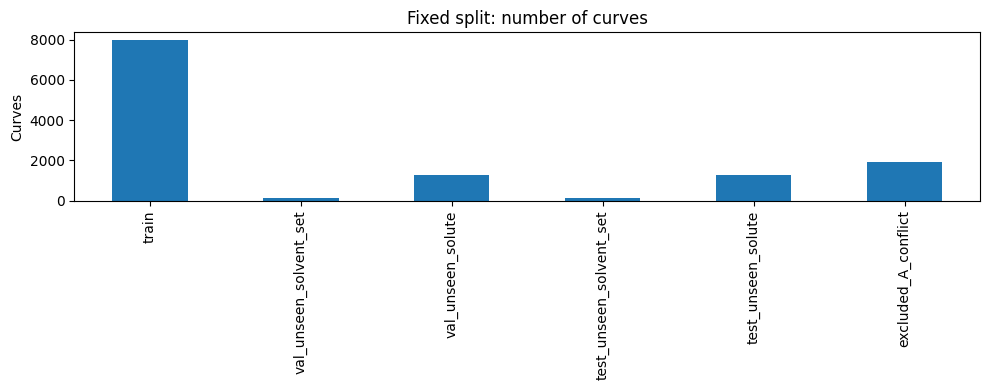

In [7]:
summary = internal.groupby("split").agg(n_internal_points=("experiment_id", "size"),
    n_curves=("experiment_id", "nunique"), n_solutes=(SOLUTE, "nunique")).reindex(ACTIVE_SPLITS + ["excluded_A_conflict"]).fillna(0)
summary[["n_internal_points", "n_curves", "n_solutes"]] = summary[["n_internal_points", "n_curves", "n_solutes"]].astype(int)
summary["curve_fraction_all"] = summary["n_curves"] / len(experiments)
summary["point_fraction_all"] = summary["n_internal_points"] / len(internal)
summary["n_solvents"] = [len(all_solvents(internal.loc[internal["split"].eq(s)])) for s in summary.index]
train_solvents = all_solvents(split_map.loc[split_map["split"].eq("train")])
known_solvent_report = split_map.copy()
known_solvent_report["solvent1_seen_in_train"] = known_solvent_report[S1].isin(train_solvents)
known_solvent_report["solvent2_seen_in_train"] = known_solvent_report[S2].isin(train_solvents)
known_solvent_report["n_solvents_seen_in_train"] = known_solvent_report["solvent1_seen_in_train"].astype(int) + known_solvent_report["solvent2_seen_in_train"].astype(int)
known_counts = known_solvent_report.groupby(["split", "n_solvents_seen_in_train"]).size().rename("n_curves").reset_index()
display(summary)
display(known_counts)
if CFG["ADD_RDKIT"]:
    missing_descriptor_report = internal.groupby("split")[RDKIT_FEATURES].agg(lambda s: int(s.isna().sum()))
    display(missing_descriptor_report)
else:
    missing_descriptor_report = pd.DataFrame()
fig, ax = plt.subplots(figsize=(10, 4))
summary["n_curves"].plot.bar(ax=ax)
ax.set(ylabel="Curves", xlabel="", title="Fixed split: number of curves")
fig.tight_layout()
plt.show()

## 7. Перенос разбиения на полную таблицу (опционально)

Если указан `INPUT_FULL`, файл должен существовать и содержать те же experiment_id.
Назначенные endpoints наследуют split своей кривой; их не следует использовать
для метрик качества прогноза внутренних составов. Разбиение повторно не генерируется.

In [8]:
full = None
if CFG["INPUT_FULL"] is not None:
    full_path = Path(CFG["INPUT_FULL"])
    if not full_path.is_file():
        raise FileNotFoundError(f"Нет {full_path}. Укажите путь или INPUT_FULL=None.")
    full = pd.read_csv(full_path, low_memory=False)
    if set(full["experiment_id"]) != set(split_map["experiment_id"]):
        raise ValueError("В full и internal различаются experiment_id. Нельзя смешивать результаты разных запусков 01.")
    reference = split_map.set_index("experiment_id")
    for column in ["system_group_id", SOLUTE, S1, S2, "Temperature_bin_K"]:
        if column not in full or not full[column].eq(full["experiment_id"].map(reference[column])).all():
            raise ValueError(f"Несовместимость full/internal в {column}")
    endpoint_reference = internal.groupby("experiment_id")[["logS1", "logS2"]].first()
    for column in ["logS1", "logS2"]:
        if not np.allclose(full[column], full["experiment_id"].map(endpoint_reference[column]), rtol=0, atol=1e-10):
            raise ValueError(f"Несовместимость full/internal в {column}")
    full = full.drop(columns=["split"], errors="ignore").merge(split_map[["experiment_id", "split"]],
                      on="experiment_id", how="left", validate="many_to_one")
    full = add_physical_features(full)
    if CFG["ADD_RDKIT"]:
        full = attach_descriptors(full, descriptor_table)
    assert full["split"].notna().all()
    print("Full:", full.shape)

Full: (125258, 64)


## 8. Сохранение

| Файл | Содержимое |
|---|---|
| `split_assignments.csv` | Одна строка на кривую, структура и split |
| `dataset_internal_with_split.csv` | Все внутренние точки, включая явно помеченный excluded |
| `splits/train.csv`, `splits/val_*.csv`, `splits/test_*.csv` | Только соответствующие рабочие выборки |
| `excluded_A_conflict.csv` | Исключённые внутренние точки |
| `feature_sets.json` | Явные разрешённые признаки для моделей |
| `solvent_descriptors.csv` | Дескрипторы уникальных растворителей |
| `reports/*.csv` | Сводки, пересечения, известность растворителей и ошибки дескрипторов |
| `manifest.json` | Параметры, версии библиотек, SHA-256 входов и выходов |

Для подбора модели можно объединять две validation-выборки, как в дипломе,
но дополнительно показывайте результаты A/B отдельно. Обе test-выборки используются
после фиксации модели и гиперпараметров. Объединённая validation в основном отражает
более многочисленный сценарий B; это нужно учитывать при интерпретации.

In [9]:
def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as stream:
        for chunk in iter(lambda: stream.read(1024*1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

out = Path(CFG["OUTPUT_DIR"])
(out / "splits").mkdir(parents=True, exist_ok=True)
(out / "reports").mkdir(exist_ok=True)
written = []
def save_table(table, relative, index=False):
    path = out / relative
    table.to_csv(path, index=index, encoding="utf-8")
    written.append(path)

save_table(split_map, "split_assignments.csv")
save_table(internal, "dataset_internal_with_split.csv")
for name in ACTIVE_SPLITS:
    save_table(internal.loc[internal["split"].eq(name)], f"splits/{name}.csv")
save_table(internal.loc[internal["split"].eq("excluded_A_conflict")], "excluded_A_conflict.csv")
if full is not None:
    save_table(full, "dataset_full_with_split.csv")
if CFG["ADD_RDKIT"]:
    save_table(descriptor_table, "solvent_descriptors.csv")
    save_table(descriptor_errors, "reports/descriptor_errors.csv")
    save_table(missing_descriptor_report, "reports/descriptor_missing_by_split.csv", index=True)
save_table(summary, "reports/split_summary.csv", index=True)
save_table(overlap_checks, "reports/overlap_checks.csv")
save_table(known_counts, "reports/known_solvents_summary.csv")
save_table(known_solvent_report, "reports/known_solvents_by_curve.csv")
save_table(a_iterations, "reports/A_iterations.csv")
save_table(solvent_counts, "reports/solvent_frequency.csv")
save_table(solute_counts, "reports/B_solute_frequency.csv")
fig.savefig(out / "reports/split_sizes.png", dpi=160, bbox_inches="tight")
(out / "feature_sets.json").write_text(json.dumps(FEATURE_SETS, indent=2), encoding="utf-8")
(out / "split_metadata.json").write_text(json.dumps(split_metadata, ensure_ascii=False, indent=2), encoding="utf-8")
inputs = [{"path": str(input_path.resolve()), "sha256": sha256_file(input_path)}]
if full is not None:
    inputs.append({"path": str(full_path.resolve()), "sha256": sha256_file(full_path)})
manifest = {"protocol": "split-features-1.0.0", "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "config": CFG, "descriptor_names": DESCRIPTOR_NAMES if CFG["ADD_RDKIT"] else [],
    "descriptor_selection": "Fixed five solvent pairs from thesis; no selection on this dataset",
    "feature_sets": FEATURE_SETS, "split_metadata": split_metadata, "inputs": inputs,
    "versions": {"python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__, "rdkit": rdBase.rdkitVersion},
    "summary": summary.reset_index().to_dict(orient="records"),
    "output_sha256": {str(p.relative_to(out)): sha256_file(p) for p in written}}
(out / "manifest.json").write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")
print("Готово:", out.resolve())
print("Для обучения: splits/train.csv и список признаков из feature_sets.json")
print("Для настройки: splits/val_unseen_solvent_set.csv и splits/val_unseen_solute.csv")

Готово: /Users/georg/projects/Solubility/Article_code/ml_ready/splits_v1
Для обучения: splits/train.csv и список признаков из feature_sets.json
Для настройки: splits/val_unseen_solvent_set.csv и splits/val_unseen_solute.csv
